# 🦋 Verifying the findings with LAM dataset

In [1]:
import time
import json
import os
import re
import pandas as pd
import base64
from IPython.display import display, Image
from PIL import Image as PILImage

# Image Encoding

In [2]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

In [3]:
images = []
for image in os.listdir('img'):
    if image.endswith('.jpg'):
        images.append(image)

rows = []
for image in images:
    # names are e.g., "003_15_22.jpg" := "page_subpage_line.jpg"
    name = image.split('.')[0]
    file_name = name.split('_')[0]
    subfile_name = name.split('_')[1]
    line_name = name.split('_')[-1]
    encoded_value = encode_image('img'+'/'+image)
    rows.append({'file': file_name, 'sub_file': subfile_name, 'line': line_name, 'encoded': encoded_value, 'id': name})

images_encoded = pd.DataFrame(rows)

In [4]:
images_encoded.head()

,file,sub_file,line,encoded,id
0,094,4405,07,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQ...,094_4405_07
1,094,4405,08,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQ...,094_4405_08
2,094,4405,05,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQ...,094_4405_05
3,094,4404,38,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQ...,094_4404_38
4,094,4404,42,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAIBAQEBAQIBAQ...,094_4404_42


In [5]:
len(images_encoded) # Because the entire list is 527MB, it got only a half.

1624

# LLMs with line-by-line

In [22]:
import llm_calls

In [ ]:
name = 'gpt_complex_output'

# Load previous progress if available
try:
    with open(f'{name}_progress.json', 'r') as file:
        result = json.load(file)
except FileNotFoundError:
    result = {}

for id in images_encoded['id'].unique(): 
# for id in unable_ids:
    # Check if this ID is already processed (Skip this step if you want to re-process for unable_ids) ----------------
    if id in result:
        print(f"Skipping {id}, already processed.")
        continue
    
    start_time = time.time()
    try:
        print(f'------- Start processing file {id} -------')
        
        # Call OpenAI/Anthropic and post-processing functions
        prompt = llm_calls.prompt_complex
        prompt += "Even if it is hard to read the texts from the image, return as much as you can. You must read something. Do not return an apologetic message."
        output = llm_calls.callOpenAI(prompt=prompt, max_tokens=800, base64_image=images_encoded[(images_encoded['id'] == id)].encoded.values[0])
        # output = callAnthropic(prompt=prompt, max_tokens=800, base64_image=images_encoded[(images_encoded['id'] == id)].encoded.values[0])
        output_cleaned = llm_calls.callPostProcessing(prompt_parameter=output)
        
        # Save the output
        result[id] = output_cleaned
        
        # Save progress after each file
        with open(f'{name}_progress.json', 'w') as file:
            json.dump(result, file)
        
        print(f'------- Finished processing file {id} in {time.time() - start_time} seconds -------')

    except Exception as e:
        print(f"Error processing file {id}: {str(e)}")
        # Save the progress and exit the loop in case of an error
        with open(f'{name}_progress.json', 'w') as file:
            json.dump(result, file)
        break  # Exit the loop on error

# Once all IDs are processed, save the final result
with open(f'{name}_output_final.json', 'w') as file:
    json.dump(result, file)

print("Processing complete.")


# TrOCR
* Now we can try with more training data.

In [2]:
img_path = '/data/brussel/vo/000/bvo00042/img'

In [3]:
from glob import glob
import json

In [4]:
with open('transcriptions.json', 'r') as f:
    tr = json.load(f)

transcriptions = pd.DataFrame(tr)

In [5]:
# images_encoded['img'] = images_encoded['id'].astype(str) + '.jpg'
# images_encoded.head()

In [6]:
# transcriptions = transcriptions[transcriptions['img'].isin(images_encoded['img'])]
# print(len(transcriptions), len(images_encoded))

In [7]:
train = transcriptions[transcriptions['nameset'] == 'train'].reset_index(drop=True)
test = transcriptions[transcriptions['nameset'] == 'test'].reset_index(drop=True)
print(f'\nTrain set length: {len(train)} \nTest set length: {len(test)}')
print(f'% train: {(len(train)/(len(test)+len(train)))*100}')


Train set length: 19830 
Test set length: 3523
% train: 84.91414379308868


In [8]:
train.head()

,decade_id,height,img,nameset,text,width
0,0,130,002_02_00.jpg,train,Lettera di Lod. Antonio,1120
1,0,147,002_02_01.jpg,train,di Giacomo Bianchi,986
2,1,112,002_04_00.jpg,train,Arona 30. 9bre. 94.,657
3,1,82,002_04_01.jpg,train,Sorella amatissima,544
4,1,93,002_04_02.jpg,train,Veramente il vostro caso è degno di compassion...,1654


In [9]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from transformers import TrOCRProcessor

# Define the class with a new name to avoid conflicts
class IAMDatasetNew(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text 
        file_name = self.df['img'][idx]
        text = self.df['text'][idx]
        # prepare image (i.e. resize + normalize)
        image = PILImage.open(self.root_dir +'/'+ file_name).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text, 
                                         padding="max_length", 
                                         max_length=self.max_target_length).input_ids
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding


processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten", use_fast=False)
train_dataset = IAMDatasetNew(root_dir=img_path,
                           df=train,
                           processor=processor)

eval_dataset = IAMDatasetNew(root_dir=img_path,
                          df=test,
                          processor=processor)

In [10]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])


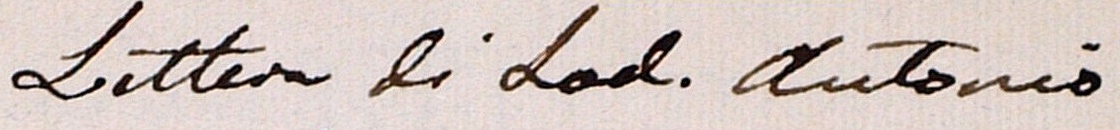

In [9]:
image = PILImage.open(train_dataset.root_dir +'/'+ train['img'][0]).convert("RGB")
image

In [10]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

Lettera di Lod. Antonio


In [11]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, ) #epoch0-7: batch_size=8; #epoch8-
eval_dataloader = DataLoader(eval_dataset, batch_size=4, shuffle=True) 

In [12]:
from transformers import VisionEncoderDecoderModel
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1").to("cpu") #I'll use cpu for resuming

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.2"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

In [13]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 200 # Change this when running it for whole scans. 
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0  # A value greater than 1.0 encourages longer sequences, while a value less than 1.0 would favor shorter ones.
model.config.num_beams = 4 # The number of beams (or different candidate sequences)

In [14]:
torch.cuda.empty_cache()

In [ ]:
from transformers import AdamW
from tqdm.notebook import tqdm

output_folder = "/data/brussel/vo/000/bvo00042/output_serene"
os.makedirs(output_folder, exist_ok=True)
checkpoint_path = os.path.join(output_folder, "checkpoint.pth")


optimizer = AdamW(model.parameters(), lr=5e-5)

# Load checkpoint if it exists
start_epoch = 10
# if os.path.exists(checkpoint_path):
#     print("Loading checkpoint...")
#     # Load checkpoint on CPU
#     checkpoint = torch.load(checkpoint_path, map_location="cpu")
#     model.load_state_dict(checkpoint["model_state_dict"])
#     # optimizer.load_state_dict(checkpoint["optimizer_state_dict"]) #This is normally large
#     model = model.to("cuda")                
#     start_epoch = checkpoint["epoch"]  # Resume the epoch
#     print(f"Resuming training from epoch {start_epoch}")

# generated_texts = {}
# start_time = time.time()

# # Added for the epochs to resume
# for param_group in optimizer.param_groups:
#     param_group["lr"] *= 0.1  # Reduce LR for a few iterations

for epoch in range(start_epoch, 16):  # Start from the last saved epoch
# for epoch in range(10):  # loop over the dataset multiple times
    print(f"Starting epoch {epoch}")
    # Train
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_dataloader):
        # Move batch data to device
        for k, v in batch.items():
            batch[k] = v.to(device)

        # Forward pass + backward pass + optimize
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()

    print(f"Loss after epoch {epoch}:", train_loss / len(train_dataloader))
    

    # Evaluate and save generated texts directly to disk
    model.eval()
    epoch_output_folder = f'{output_folder}/epoch{epoch}'
    os.makedirs(epoch_output_folder, exist_ok=True)

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(eval_dataloader)):
            print(f'Generating text for epoch {epoch}, batch {batch_idx}')
            outputs = model.generate(batch["pixel_values"].to(device))
            decoded_text = processor.batch_decode(outputs, skip_special_tokens=True)[0]

            # Save the generated text directly to disk
            find_filename = test['img'][batch_idx] if batch_idx < len(test) else f'unknown_{batch_idx}'
            output_path = os.path.join(epoch_output_folder, f'{find_filename}_epoch_{epoch}_batch_{batch_idx}.txt')
            with open(output_path, "w") as f:
                f.write(decoded_text)

            # Clear unnecessary variables
            del outputs, decoded_text

    # Optionally clear the GPU cache if using CUDA
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Save the trained model
model.save_pretrained(output_folder)
print("✅ Finished Training and Saving the model: time taken = ", time.time() - start_time)

Starting epoch 10


/apps/brussel/RL8/broadwell/software/Transformers/4.48.2-gfbf-2023a-tokenizers-0.21.0/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


  0%|          | 0/4958 [00:00<?, ?it/s]

Loss after epoch 10: 0.5565988859199303


  0%|          | 0/881 [00:00<?, ?it/s]

...

  0%|          | 0/4958 [00:00<?, ?it/s]

Loss after epoch 11: 0.585362045228866


  0%|          | 0/881 [00:00<?, ?it/s]

Generating text for epoch 11, batch 0
Generating text for epoch 11, batch 1
Generating text for epoch 11, batch 2
Generating text for epoch 11, batch 3
Generating text for epoch 11, batch 4
Generating text for epoch 11, batch 5
Generating text for epoch 11, batch 6
Generating text for epoch 11, batch 7
Generating text for epoch 11, batch 8
Generating text for epoch 11, batch 9
Generating text for epoch 11, batch 10
Generating text for epoch 11, batch 11
Generating text for epoch 11, batch 12
Generating text for epoch 11, batch 13
Generating text for epoch 11, batch 14
Generating text for epoch 11, batch 15
Generating text for epoch 11, batch 16
Generating text for epoch 11, batch 17
Generating text for epoch 11, batch 18
Generating text for epoch 11, batch 19
Generating text for epoch 11, batch 20
Generating text for epoch 11, batch 21
Generating text for epoch 11, batch 22
Generating text for epoch 11, batch 23
Generating text for epoch 11, batch 24
Generating text for epoch 11, batch

  0%|          | 0/4958 [00:00<?, ?it/s]

In [22]:
checkpoint_path = os.path.join(output_folder, "checkpoint.pth")
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": train_loss
}, checkpoint_path)

In [21]:
output_folder

'/data/brussel/vo/000/bvo00042/output_serene'